In [1]:
library(dada2); packageVersion("dada2")
options(repr.vector.latex = FALSE,
        repr.matrix.latex = FALSE,
        repr.data.frame.latex = FALSE)


Loading required package: Rcpp



[1] ‘1.16.0’

In [2]:
getOption("repr.vector.latex")

[1] FALSE

In [3]:
getOption("repr.matrix.latex")


[1] FALSE

In [4]:
path <- "/data1/ccs_data/data2-demo-data/MiSeq_SOP"
files <- list.files(path)
print(files)

 [1] "F3D0_S188_L001_R1_001.fastq"   "F3D0_S188_L001_R2_001.fastq"  
 [3] "F3D1_S189_L001_R1_001.fastq"   "F3D1_S189_L001_R2_001.fastq"  
 [5] "F3D141_S207_L001_R1_001.fastq" "F3D141_S207_L001_R2_001.fastq"
 [7] "F3D142_S208_L001_R1_001.fastq" "F3D142_S208_L001_R2_001.fastq"
 [9] "F3D143_S209_L001_R1_001.fastq" "F3D143_S209_L001_R2_001.fastq"
[11] "F3D144_S210_L001_R1_001.fastq" "F3D144_S210_L001_R2_001.fastq"
[13] "F3D145_S211_L001_R1_001.fastq" "F3D145_S211_L001_R2_001.fastq"
[15] "F3D146_S212_L001_R1_001.fastq" "F3D146_S212_L001_R2_001.fastq"
[17] "F3D147_S213_L001_R1_001.fastq" "F3D147_S213_L001_R2_001.fastq"
[19] "F3D148_S214_L001_R1_001.fastq" "F3D148_S214_L001_R2_001.fastq"
[21] "F3D149_S215_L001_R1_001.fastq" "F3D149_S215_L001_R2_001.fastq"
[23] "F3D150_S216_L001_R1_001.fastq" "F3D150_S216_L001_R2_001.fastq"
[25] "F3D2_S190_L001_R1_001.fastq"   "F3D2_S190_L001_R2_001.fastq"  
[27] "F3D3_S191_L001_R1_001.fastq"   "F3D3_S191_L001_R2_001.fastq"  
[29] "F3D5_S193_L001_R1_001.fastq"

In [5]:
fnFs <- sort(list.files(path, pattern="_R1_001.fastq", full.names = TRUE))
fnRs <- sort(list.files(path, pattern="_R2_001.fastq", full.names = TRUE))

sample.names <- sapply(strsplit(basename(fnFs), "_"), `[`, 1)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the dada2 package.
  Please report the issue at <https://github.com/benjjneb/dada2/issues>.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the dada2 package.
  Please report the issue at <https://github.com/benjjneb/dada2/issues>.”


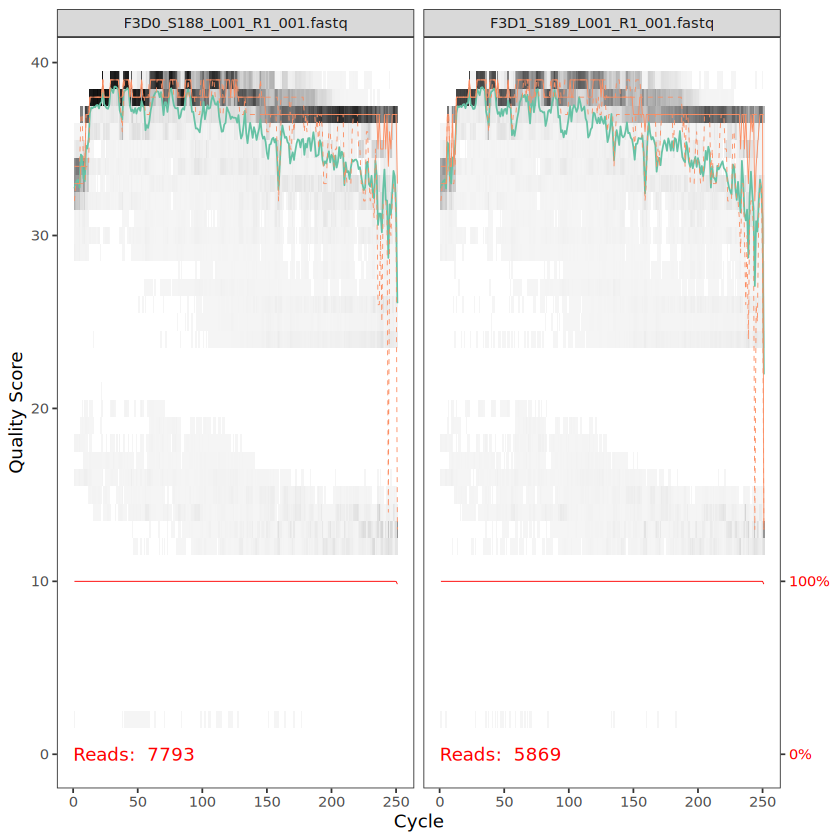

In [6]:
plotQualityProfile(fnFs[1:2])


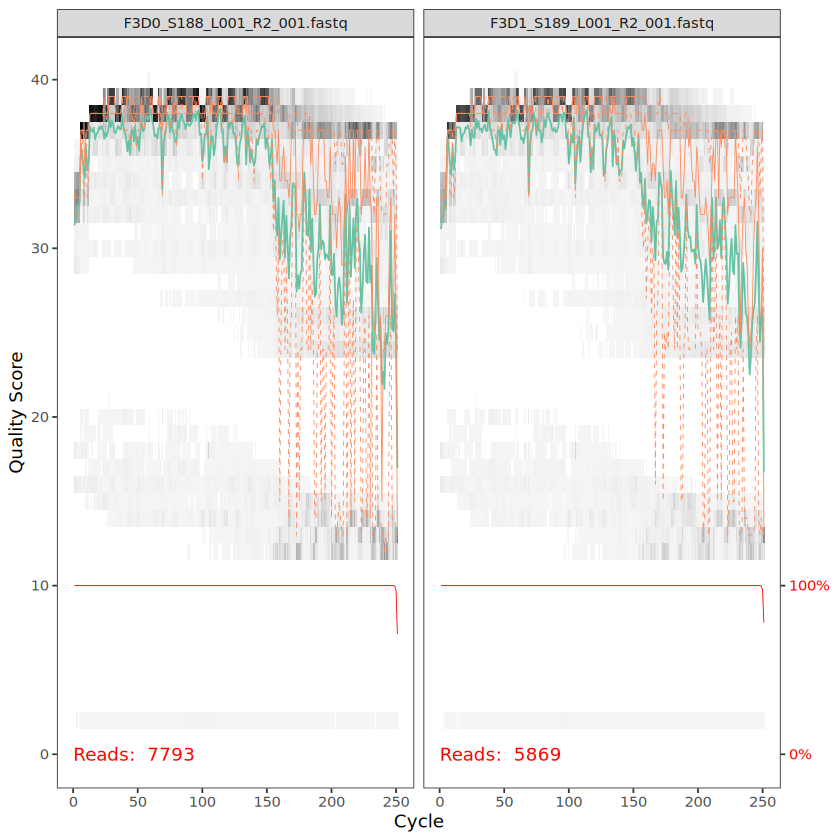

In [7]:
plotQualityProfile(fnRs[1:2])


In [8]:
filtFs <- file.path(path, "filtered", paste0(sample.names, "_F_filt.fastq.gz"))
filtRs <- file.path(path, "filtered", paste0(sample.names, "_R_filt.fastq.gz"))
names(filtFs) <- sample.names
names(filtRs) <- sample.names


out <- filterAndTrim(fnFs, filtFs, fnRs, filtRs, truncLen=c(240,160),
              maxN=0, maxEE=c(2,2), truncQ=2, rm.phix=TRUE,
              compress=TRUE, multithread=TRUE) # On Windows set multithread=FALSE (only needed for filterAndTrim)
print(out)

                              reads.in reads.out
F3D0_S188_L001_R1_001.fastq       7793      7113
F3D1_S189_L001_R1_001.fastq       5869      5299
F3D141_S207_L001_R1_001.fastq     5958      5463
F3D142_S208_L001_R1_001.fastq     3183      2914
F3D143_S209_L001_R1_001.fastq     3178      2941
F3D144_S210_L001_R1_001.fastq     4827      4312
F3D145_S211_L001_R1_001.fastq     7377      6741
F3D146_S212_L001_R1_001.fastq     5021      4560
F3D147_S213_L001_R1_001.fastq    17070     15637
F3D148_S214_L001_R1_001.fastq    12405     11413
F3D149_S215_L001_R1_001.fastq    13083     12017
F3D150_S216_L001_R1_001.fastq     5509      5032
F3D2_S190_L001_R1_001.fastq      19620     18075
F3D3_S191_L001_R1_001.fastq       6758      6250
F3D5_S193_L001_R1_001.fastq       4448      4052
F3D6_S194_L001_R1_001.fastq       7989      7369
F3D7_S195_L001_R1_001.fastq       5129      4765
F3D8_S196_L001_R1_001.fastq       5294      4871
F3D9_S197_L001_R1_001.fastq       7070      6504
Mock_S280_L001_R1_00

In [17]:
errF <- learnErrors(filtFs, errorEstimationFunction = PacBioErrfun, multithread=TRUE)

33514080 total bases in 139642 reads from 20 samples will be used for learning the error rates.


The max qual score of 93 was not detected. Using standard error fitting.

The max qual score of 93 was not detected. Using standard error fitting.

The max qual score of 93 was not detected. Using standard error fitting.

The max qual score of 93 was not detected. Using standard error fitting.

The max qual score of 93 was not detected. Using standard error fitting.

The max qual score of 93 was not detected. Using standard error fitting.



In [10]:
errR <- learnErrors(filtRs, multithread=TRUE)


22342720 total bases in 139642 reads from 20 samples will be used for learning the error rates.


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


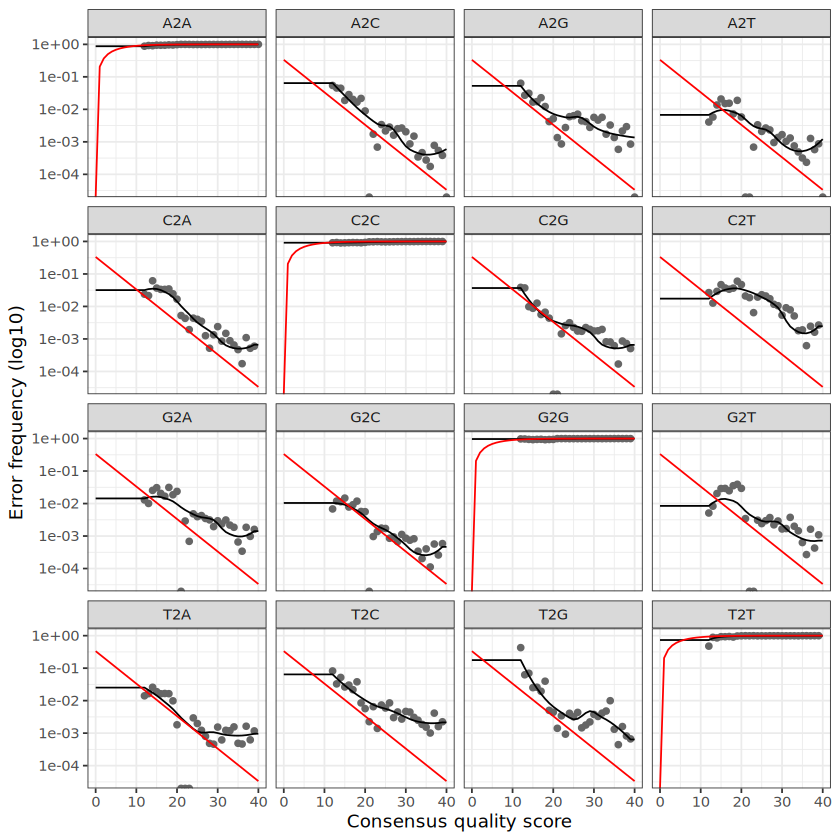

In [18]:
plotErrors(errF, nominalQ=TRUE)


In [12]:
dadaFs <- dada(filtFs, err=errF, multithread=TRUE)

Sample 1 - 7113 reads in 1979 unique sequences.
Sample 2 - 5299 reads in 1639 unique sequences.
Sample 3 - 5463 reads in 1477 unique sequences.
Sample 4 - 2914 reads in 904 unique sequences.
Sample 5 - 2941 reads in 939 unique sequences.
Sample 6 - 4312 reads in 1267 unique sequences.
Sample 7 - 6741 reads in 1756 unique sequences.
Sample 8 - 4560 reads in 1438 unique sequences.
Sample 9 - 15637 reads in 3590 unique sequences.
Sample 10 - 11413 reads in 2762 unique sequences.
Sample 11 - 12017 reads in 3021 unique sequences.
Sample 12 - 5032 reads in 1566 unique sequences.
Sample 13 - 18075 reads in 3707 unique sequences.
Sample 14 - 6250 reads in 1479 unique sequences.
Sample 15 - 4052 reads in 1195 unique sequences.
Sample 16 - 7369 reads in 1832 unique sequences.
Sample 17 - 4765 reads in 1183 unique sequences.
Sample 18 - 4871 reads in 1382 unique sequences.
Sample 19 - 6504 reads in 1709 unique sequences.
Sample 20 - 4314 reads in 897 unique sequences.


In [13]:
dadaRs <- dada(filtRs, err=errR, multithread=TRUE)


Sample 1 - 7113 reads in 1660 unique sequences.
Sample 2 - 5299 reads in 1349 unique sequences.
Sample 3 - 5463 reads in 1335 unique sequences.
Sample 4 - 2914 reads in 853 unique sequences.
Sample 5 - 2941 reads in 880 unique sequences.
Sample 6 - 4312 reads in 1286 unique sequences.
Sample 7 - 6741 reads in 1803 unique sequences.
Sample 8 - 4560 reads in 1265 unique sequences.
Sample 9 - 15637 reads in 3414 unique sequences.
Sample 10 - 11413 reads in 2522 unique sequences.
Sample 11 - 12017 reads in 2771 unique sequences.
Sample 12 - 5032 reads in 1415 unique sequences.
Sample 13 - 18075 reads in 3290 unique sequences.
Sample 14 - 6250 reads in 1390 unique sequences.
Sample 15 - 4052 reads in 1134 unique sequences.
Sample 16 - 7369 reads in 1635 unique sequences.
Sample 17 - 4765 reads in 1084 unique sequences.
Sample 18 - 4871 reads in 1161 unique sequences.
Sample 19 - 6504 reads in 1502 unique sequences.
Sample 20 - 4314 reads in 732 unique sequences.


In [15]:
print(dadaFs[[1]])


dada-class: object describing DADA2 denoising results
128 sequence variants were inferred from 1979 input unique sequences.
Key parameters: OMEGA_A = 1e-40, OMEGA_C = 1e-40, BAND_SIZE = 16
